# 4 Evaluation

## 4.01 Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [4]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [5]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [6]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

## 4.02 Accuracy and dummy model

In [8]:
total = len(y_val)

In [9]:
# correct decisions mades
correct = (y_val == churn_decision).sum()

In [10]:
accuracy = correct / total 
print(accuracy)

0.8034066713981547


In [11]:
from sklearn.metrics import accuracy_score

In [12]:
thresholds = np.linspace(0, 1, 51)

scores = []

for t in thresholds:
    churn_decision = (y_pred >= t)
    acc = accuracy_score(y_val, y_pred >= t)
   # print(f"Threshold {t:.3f} | Acc {acc:.4f}")
    scores.append(acc)

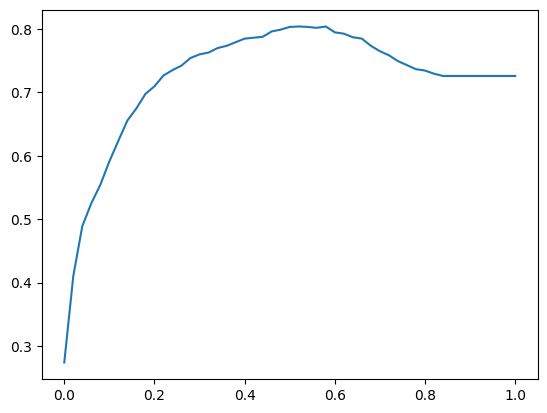

In [13]:
plt.plot(thresholds, scores)

In [14]:
from collections import Counter
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

## 4.03 Confusion table

In [15]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [16]:
t = 0.5
pred_positive = (y_pred >= t)
pred_negative = (y_pred < t)

In [17]:
TP = (actual_positive & pred_positive).sum()
TN = (actual_negative & pred_negative).sum()
FP = (actual_negative & pred_positive).sum()
FN = (actual_positive & pred_negative).sum()

In [18]:
confusion_matrix = np.array([
    [TN, FP],
    [FN, TP]
])
print(confusion_matrix)

[[922 101]
 [176 210]]


In [19]:
print(confusion_matrix/confusion_matrix.sum())

[[0.6543648  0.07168204]
 [0.12491128 0.14904187]]


## 4.04 Precision and Recall

In [20]:
acc = (TP+TN)/(TP+TN+FP+FN)
acc

np.float64(0.8034066713981547)

In [21]:
precision = TP / (TP+FP)
precision

np.float64(0.6752411575562701)

In [22]:
recall = TP / (TP+FN)
recall

np.float64(0.5440414507772021)

## 4.05 ROC Curves

In [23]:
tpr = TP/(TP+FN)
tpr # this is equivalent to recall.

np.float64(0.5440414507772021)

In [24]:
fpr = FP/(FP+TN)
fpr

np.float64(0.09872922776148582)

In [25]:
thresholds = np.linspace(0, 1, 101)

actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

tprs, fprs = [], []
for t in thresholds:
    pred_positive = (y_pred >= t)
    pred_negative = (y_pred < t)
    TP = (actual_positive & pred_positive).sum()
    TN = (actual_negative & pred_negative).sum()
    FP = (actual_negative & pred_positive).sum()
    FN = (actual_positive & pred_negative).sum()
    tpr = TP/(TP+FN)
    fpr = FP/(FP+TN)
    tprs.append(tpr)
    fprs.append(fpr)
    

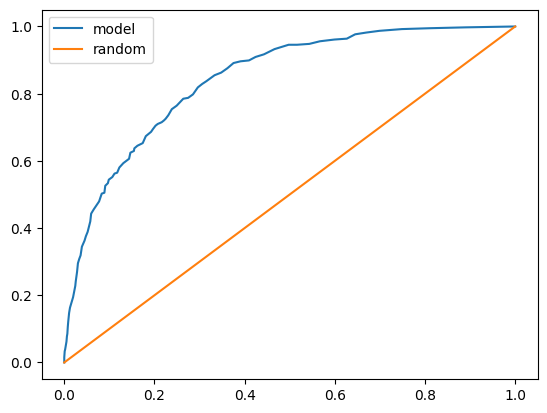

In [26]:
plt.plot(fprs, tprs, label="model")
plt.plot([0,1],[0,1], label="random")
plt.legend()

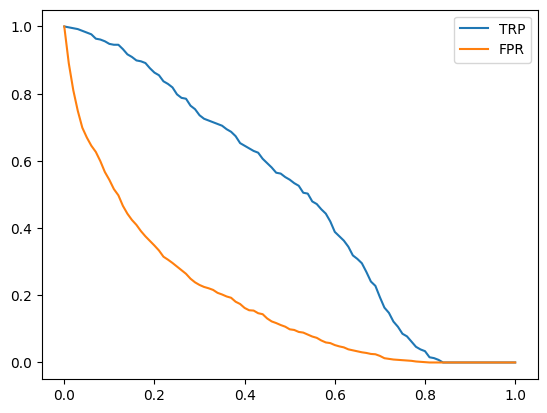

In [27]:
plt.plot(thresholds, tprs, label="TRP")
plt.plot(thresholds, fprs, label="FPR")
plt.legend()

In [28]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size=len(y_val))

In [29]:
((y_rand >= 0.5) == y_val).mean()

np.float64(0.5017743080198722)

In [30]:
num_neg = (y_val==0).sum()
num_pos = (y_val==1).sum()
num_neg, num_pos

(np.int64(1023), np.int64(386))

In [31]:
y_ideal = np.repeat([0,1],[num_neg, num_pos])
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [32]:
y_ideal_pred = np.linspace(0, 1, len(y_val))

In [33]:
((y_ideal_pred >= 0.726) == y_ideal).mean()

np.float64(1.0)

In [34]:
from sklearn.metrics import roc_curve

fpr, tpr, ths = roc_curve(y_val, y_pred)

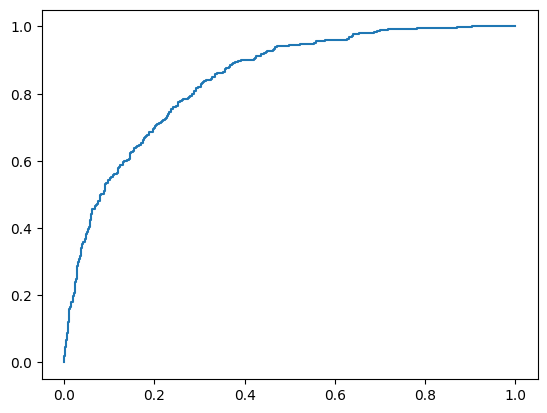

In [35]:
plt.plot(fpr, tpr)

## 4.06 ROC AUC

In [38]:
from sklearn.metrics import auc

In [39]:
auc(fpr, tpr)

0.8438454408703447

In [45]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_val, y_pred)

0.8438454408703447

In [54]:
neg = y_pred[y_val==0]
pos = y_pred[y_val==1]

In [62]:
import random

n = 10_000_000
success = 0
outcome = []
for i in range(n):
    pos_ind = random.randint(0, len(pos)-1)
    neg_ind = random.randint(0, len(neg)-1)
    outcome.append(pos[pos_ind] > neg[neg_ind])
np.mean(outcome)

np.float64(0.8438649)

In [61]:
n = 10_000_000
pos_idx = np.random.randint(0, len(pos), size=n)
neg_idx = np.random.randint(0, len(neg), size=n)

(pos[pos_idx] > neg[neg_idx]).mean()


np.float64(0.8437959)

## 4.07 Cross-validation

In [107]:
def train(df_train, y, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer()
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=10_000)
    model.fit(X_train, y)

    return dv, model


In [108]:
dv, model = train(df_train, y_train)

In [109]:
def predict(df, dv, model):
    dicts = df[categorical+numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:,1]

    return y_pred


In [110]:
y_pred = predict(df_val, dv, model)

In [111]:
from sklearn.model_selection import KFold

In [112]:
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
train_idx, val_idx = next(kfold.split(df_full_train))

In [113]:
from tqdm.auto import tqdm

In [114]:
scores = []
for train_idx, val_idx in tqdm(kfold.split(df_full_train)):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.churn.values
    y_val = df_val.churn.values

    dv, model = train(df_train, y_train, C=0.01)
    y_pred = predict(df_val, dv, model)
    
    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)


0it [00:00, ?it/s]

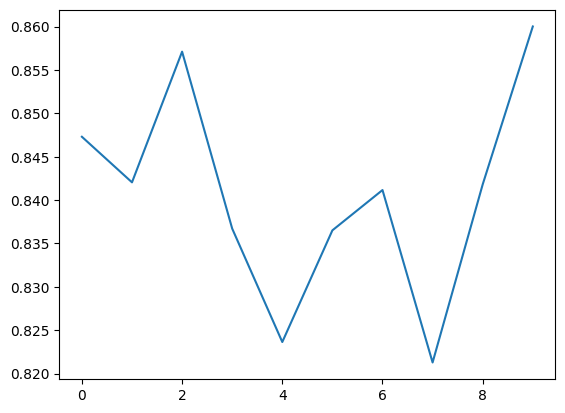

In [115]:
plt.plot(scores)

In [116]:
np.mean(scores), np.std(scores)

(np.float64(0.8407598504893734), np.float64(0.01179654478436207))

In [117]:
dv, model = train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_test, dv, model)
auc = roc_auc_score(y_test, y_pred)

In [118]:
print(f"Test auc: {auc}")

Test auc: 0.8584682093449033
